# Hierarchical Clustering - Model Development Workflow (Penguin Morphology)

> **MLCourse · Machine Learning · unsupervised**

### What you'll learn
1. Run the full hierarchical pipeline on REAL morphology data: 333 penguins,
   4 measurements (bill length/depth, flipper length, body mass)
2. Read a **full AND truncated ward dendrogram**, then cut it at k=3
   with `AgglomerativeClustering`
3. Sanity-check discovered clusters against true species (Adelie/Chinstrap
   mixing is EXPECTED - we'll discuss why)
4. Trace silhouette across CUT HEIGHTS instead of guessing where to slice

⚠️ `species` is quarantined for evaluation ONLY - it never touches scaling
or fitting. We are rediscovering penguin taxonomy blind.

### Setup cell


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster  # tree toolkit

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course resolver: walk up to '02_machine_learning'; download once."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("course data folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)
    return fpath

PENGUINS_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"


### 1. Load & explore


In [2]:
peng = pd.read_csv(get_data("penguins.csv", PENGUINS_URL)).dropna()  # few NaNs -> drop
species_truth = peng.pop("species")            # quarantine ground truth (eval only)
morph_cols = ["bill_length_mm", "bill_depth_mm",
              "flipper_length_mm", "body_mass_g"]
print(peng.shape, "| species mix:", species_truth.value_counts().to_dict())
peng[morph_cols].describe().round(1)

(333, 6) | species mix: {'Adelie': 146, 'Gentoo': 119, 'Chinstrap': 68}


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.0,333.0,333.0,333.0
mean,44.0,17.2,201.0,4207.1
std,5.5,2.0,14.0,805.2
min,32.1,13.1,172.0,2700.0
25%,39.5,15.6,190.0,3550.0
50%,44.5,17.3,197.0,4050.0
75%,48.6,18.7,213.0,4775.0
max,59.6,21.5,231.0,6300.0


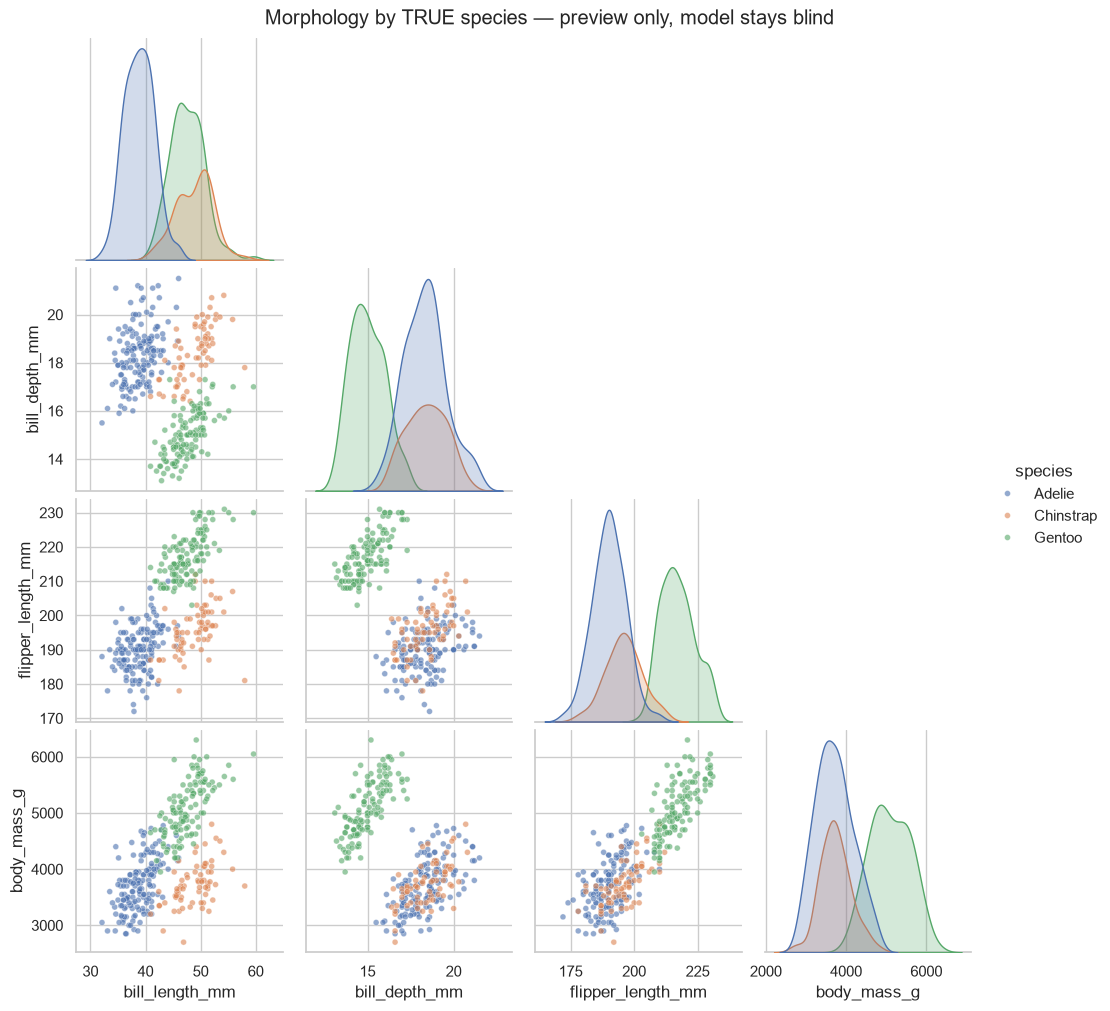

In [3]:
sns.pairplot(pd.concat([peng[morph_cols], species_truth], axis=1),  # EDA incl truth VIEW
             hue="species", corner=True,
             plot_kws=dict(s=18, alpha=0.6, edgecolor="white"))
plt.suptitle("Morphology by TRUE species - preview only, model stays blind", y=1.01)
plt.show()

💡 The pairplot previews what blind clustering will face: Adelie vs Gentoo
separate strongly on flipper/bill_depth; Chinstrap overlaps Adelie heavily on
most axes (only bill LENGTH really separates them). Keep that in mind when
judging results later.

### 2. Processing - scale all four numeric features

Body mass (2700-6300 g) would obliterate bill depth (13-22 mm) in raw
Euclidean distance. StandardScaler equalizes every axis.

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(peng[morph_cols])      # (333, 4) comparable coordinates
pd.DataFrame(X, columns=morph_cols).agg(["mean", "std"]).round(2)  # sanity: 0/1

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
mean,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0


### 3. Modeling - build & read the ward dendrogram


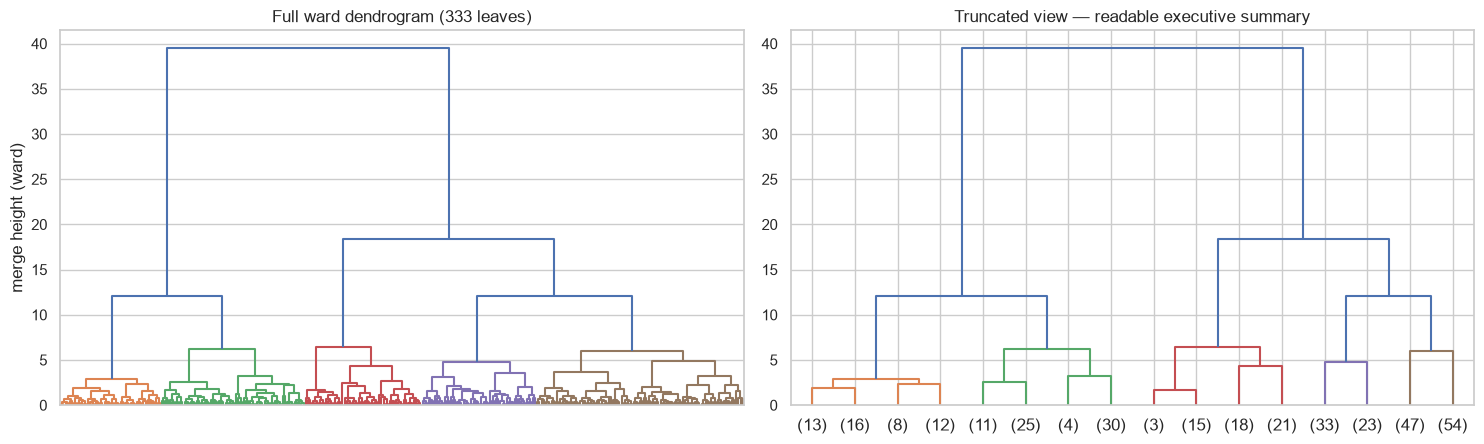

In [5]:
Z = linkage(X, method="ward")                   # merge table: (332, 4) rows = merges

fig, (ax_full, ax_trunc) = plt.subplots(1, 2, figsize=(15, 4.6))
dendrogram(Z, no_labels=True, ax=ax_full,       # FULL tree: all 333 leaves
           color_threshold=12)                  # colour branches below threshold
ax_full.set_title("Full ward dendrogram (333 leaves)")
ax_full.set_ylabel("merge height (ward)")

dendrogram(Z, truncate_mode="level", p=3,       # TRUNCATED: top-3 levels only
           ax=ax_trunc, color_threshold=12)     # leaf counts shown in brackets
ax_trunc.set_title("Truncated view - readable executive summary")
plt.tight_layout(); plt.show()

Reading the trees: the topmost merges happen around height ~25-35, then a
long empty vertical stretch before activity resumes near ~10-12 - a classic
signal to cut somewhere in that gap.

In [6]:
for h in (30, 15, 11):                          # what does each candidate cut give?
    k = len(np.unique(fcluster(Z, t=h, criterion="distance")))
    print(f"cut at height {h:>4} -> {k} clusters")

cut at height   30 -> 2 clusters
cut at height   15 -> 3 clusters
cut at height   11 -> 5 clusters


### 4. Cut at k=3 and sanity-check against species


In [7]:
agg3 = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X)
peng["cluster"] = agg3.labels_                  # attach flat labels

crosstab = pd.crosstab(peng["cluster"], species_truth)   # discovered x truth
display(crosstab)                               # noqa: F821
print(f"silhouette at this cut: {silhouette_score(X, agg3.labels_):.3f}")

species,Adelie,Chinstrap,Gentoo
cluster,,,
0,0,0,119
1,146,11,0
2,0,57,0


silhouette at this cut: 0.452


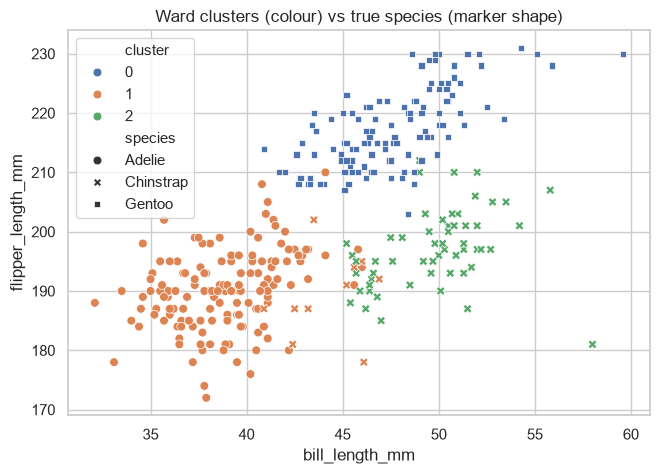

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5))        # project back to 2 informative dims
sns.scatterplot(data=peng, x="bill_length_mm", y="flipper_length_mm",
                hue="cluster", palette="deep", style=species_truth,
                s=40, edgecolor="white", ax=ax)
ax.set_title("Ward clusters (colour) vs true species (marker shape)")
plt.show()

⚠️ Sanity-check verdict: one cluster ≈ pure Gentoo, but TWO species collapse
together - Chinstrap rides inside an Adelie-dominated cluster. Exactly what
the pairplot foreshadowed: in these four features Chinstrap differs from
Adelie mainly via bill length, not enough for ward's spherical preference.
Blind ≠ omniscient; report the mix honestly.

### 5. Silhouette across cut heights (choose the slice scientifically)

Instead of eyeballing the tree, sweep the cut height with scipy's
`fcluster(..., criterion="maxclust")`: each height induces some k; score each.

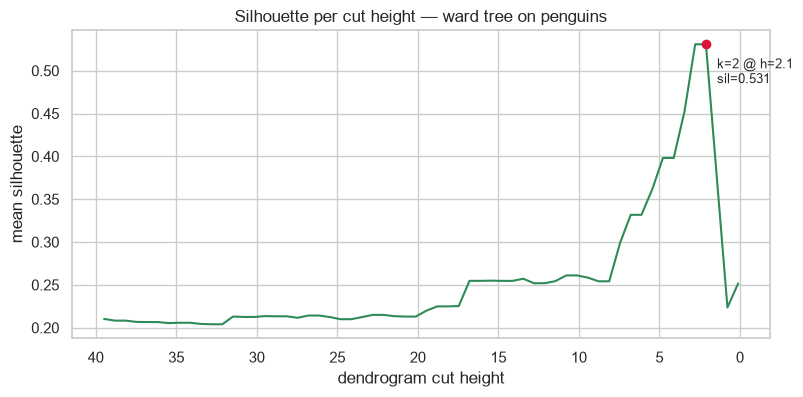

k
2    0.531
3    0.452
4    0.398
5    0.361
6    0.332
7    0.299
8    0.254
9    0.259
Name: silhouette, dtype: float64

In [9]:
heights = np.linspace(Z[:, 2].min(), Z[:, 2].max(), 60)[::-1]  # tall -> short cuts
rows = []
for h in heights:                               # evaluate every candidate slice
    lab = fcluster(Z, t=h, criterion="maxclust")
    k = len(np.unique(lab))
    if k >= 2 and k <= len(X):                  # silhouette needs >=2 clusters
        rows.append({"cut_height": h, "k": k,
                     "silhouette": silhouette_score(X, lab)})
cuts = pd.DataFrame(rows).sort_values("cut_height").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cuts["cut_height"], cuts["silhouette"], color="seagreen")
best = cuts.loc[cuts["silhouette"].idxmax()]    # data-champion slice
ax.scatter(best.cut_height, best.silhouette, color="crimson", zorder=5)
ax.annotate(f"k={int(best.k)} @ h={best.cut_height:.1f}\nsil={best.silhouette:.3f}",
            (best.cut_height, best.silhouette),
            textcoords="offset points", xytext=(8, -28), fontsize=9)
ax.invert_xaxis()                               # natural reading: cut descending
ax.set_xlabel("dendrogram cut height"); ax.set_ylabel("mean silhouette")
ax.set_title("Silhouette per cut height - ward tree on penguins")
plt.show()

cuts.groupby("k")["silhouette"].max().head(8).round(3)   # best score per k

### Summary

- Pipeline: load → quarantine labels → scale → `linkage(ward)` → READ tree
  (full + truncated) → cut (`AgglomerativeClustering` or `fcluster`) →
  crosstab sanity → silhouette-per-height refinement.
- Ward recovered Gentoo cleanly; Adelie/Chinstrap partially merged because
  their morphology overlaps in these four features.
- Silhouette-vs-cut-height turns dendrogram slicing from art into measurement;
  here k=2 scores highest (Gentoo vs the rest), while k=3 remains the more
  informative business answer.
- ⚠️ No `.predict()` exists for new penguins - production scoring requires a
  nearest-centroid wrapper or a different model family.